In [1]:
import numpy as np
from scipy.ndimage import uniform_filter

# --- 1️⃣ Original Matrix ---
A = np.array([
    [2, 4, 6, 1, 1],
    [3, 7, 6, 2, 0],
    [4, 7, 2, 5, 4],
    [3, 0, 6, 2, 1],
    [5, 7, 5, 1, 2]
], dtype=float)

kr, kc = 3, 3  # Kernel size

# --- 2️⃣ Apply Geometric Mean Filter ---
# (1) Take logarithm of all values (add a small epsilon to avoid log(0))
logA = np.log(A + 1e-8)

# (2) Apply mean filter (equivalent to imfilter(log(A), ones(kr,kc)/k^2))
mean_log = uniform_filter(logA, size=(kr, kc), mode='nearest')

# (3) Exponentiate and take the (1/(kr*kc))th power
f = np.exp(mean_log) ** (1 / (kr * kc))

# --- 3️⃣ Display Results ---
print("Original Matrix:")
print(A)

print("\nAfter Geometric Mean Filter (resultant matrix):")
print(np.round(f, 3))


Original Matrix:
[[2. 4. 6. 1. 1.]
 [3. 7. 6. 2. 0.]
 [4. 7. 2. 5. 4.]
 [3. 0. 6. 2. 1.]
 [5. 7. 5. 1. 2.]]

After Geometric Mean Filter (resultant matrix):
[[1.127 1.168 1.142 0.859 0.64 ]
 [1.154 1.17  1.158 0.879 0.676]
 [0.913 0.921 0.914 0.886 0.681]
 [0.925 0.925 0.904 1.11  1.083]
 [0.93  0.938 0.897 1.091 1.044]]


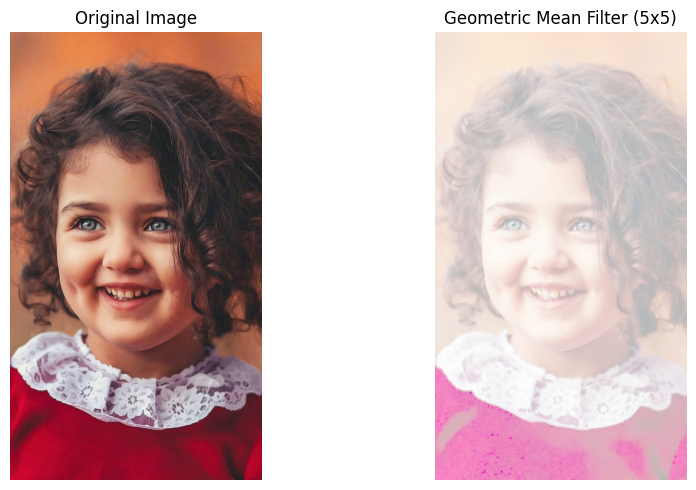

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

# --- 1️⃣ Read the image ---
I = cv2.imread('pk.jpg')  # Load image
if I is None:
    raise ValueError("Image not found. Please make sure 'pk.jpg' is in the same folder.")
I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB for display

# --- 2️⃣ Define kernel size ---
k = 5  # Kernel size (5x5)

# --- 3️⃣ Apply Geometric Mean Filter (channel-wise) ---
geom_filtered = np.zeros_like(I, dtype=np.float32)
for c in range(3):  # For each color channel (R, G, B)
    channel = I[:, :, c].astype(np.float32) + 1e-8  # Avoid log(0)
    log_channel = np.log(channel)
    mean_log = uniform_filter(log_channel, size=(k, k), mode='nearest')
    geom = np.exp(mean_log) ** (1 / (k * k))
    geom_filtered[:, :, c] = geom

# --- 4️⃣ Normalize and convert back to uint8 ---
geom_filtered = cv2.normalize(geom_filtered, None, 0, 255, cv2.NORM_MINMAX)
geom_filtered = np.uint8(geom_filtered)

# --- 5️⃣ Display results ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(I)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(geom_filtered)
plt.title(f'Geometric Mean Filter ({k}x{k})')
plt.axis('off')

plt.tight_layout()
plt.show()
